In [25]:
# --- Main Configuration Cell ---

# 1. Data Generation Settings
DATA_CONFIG = {
    'output_dir': 'data',
    'num_aircraft': 5,
    'num_anomalous_aircraft': 1,
    'flight_duration_hours': 24,
    'points_per_hour': 60,
    'sensor_names': ['engine_rpm', 'fuel_flow', 'engine_temperature', 'vibration_level']
}

# 2. Model Architecture
MODEL_CONFIG = {
    'input_dim': len(DATA_CONFIG['sensor_names']),
    'hidden_dim': 32,
    'latent_dim': 8
}

# 3. Training Parameters
TRAINING_CONFIG = {
    'centralized_epochs': 50,
    'federated_rounds': 10,
    'federated_local_epochs': 5,
    'learning_rate': 0.001,
}

print("✅ Configuration loaded.")

✅ Configuration loaded.


In [26]:
import os
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler

from anomfl.data_generation.aircraft_data_generator import Fleet
from anomfl.autoencoders.autoencoder import Autoencoder
from anomfl.federated.centralized_server import FederatedClient, CentralizedServer

print("✅ Libraries imported.")

✅ Libraries imported.


In [27]:
print("--- Starting Data Generation ---")

# Clean up old data directory
if os.path.exists(DATA_CONFIG['output_dir']):
    shutil.rmtree(DATA_CONFIG['output_dir'])

# Calculate parameters for the Fleet class
FLEET_ID = 1
num_points = DATA_CONFIG['flight_duration_hours'] * DATA_CONFIG['points_per_hour']
interval_minutes = 60 // DATA_CONFIG['points_per_hour']

# Create the Fleet object
fleet = Fleet(
    fleet_id=FLEET_ID,
    num_aircraft=DATA_CONFIG['num_aircraft'],
    num_anomalous=DATA_CONFIG['num_anomalous_aircraft'],
    num_points=num_points,
    interval_minutes=interval_minutes
)

# Generate and save the data
fleet.generate_fleet_data(output_dir=DATA_CONFIG['output_dir'])

# Store file paths for later use
anomalous_ids = {record['aircraft_id'] for record in fleet.anomaly_records}
file_paths = []
for aircraft in fleet.aircraft_list:
    suffix = "_anomalous.csv" if aircraft.id in anomalous_ids else "_normal.csv"
    path = os.path.join(DATA_CONFIG['output_dir'], f"fleet_{FLEET_ID}", f"aircraft_{FLEET_ID}_{aircraft.id}{suffix}")
    file_paths.append(path)

print(f"\n✅ Data generation complete.")

--- Starting Data Generation ---
📁 Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_1_normal.csv
🛩️ Aircraft 1-1 generated (Normal)
📁 Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_2_normal.csv
🛩️ Aircraft 1-2 generated (Normal)
📁 Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_3_anomalous.csv
🛩️ Aircraft 1-3 generated (Anomalous)
📁 Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_4_normal.csv
🛩️ Aircraft 1-4 generated (Normal)
📁 Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_5_normal.csv
🛩️ Aircraft 1-5 generated (Normal)
📝 Anomaly summary saved as d:\DL\FL\AnomFL\examples\data\fleet_1\fleet_1_anomalies.csv

✅ Data generation complete.


In [28]:
print("\n--- Training Centralized Model ---")

# Load data ONLY from normal aircraft
normal_paths = [path for path in file_paths if "normal" in path]
normal_dfs = [pd.read_csv(p) for p in normal_paths]
all_normal_data_df = pd.concat(normal_dfs, ignore_index=True)
sensor_data = all_normal_data_df[DATA_CONFIG['sensor_names']]

# Fit a single scaler on the normal data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(sensor_data)
train_tensor = torch.tensor(scaled_data, dtype=torch.float32)

# Instantiate and train the model
centralized_model = Autoencoder(
    input_dim=MODEL_CONFIG['input_dim'],
    hidden_dim=MODEL_CONFIG['hidden_dim'],
    latent_dim=MODEL_CONFIG['latent_dim']
)
centralized_model.train_on_tensor(
    train_tensor,
    num_epochs=TRAINING_CONFIG['centralized_epochs'],
    lr=TRAINING_CONFIG['learning_rate']
)

# Calculate and print final MSE statistic
centralized_model.eval()
with torch.no_grad():
    reconstructed = centralized_model(train_tensor)
    final_loss = nn.MSELoss()(reconstructed, train_tensor)
print(f"\n📊 Final MSE on Normal Training Data (Centralized): {final_loss.item():.8f}")


--- Training Centralized Model ---
Starting training...
  Epoch [10/50], Loss: 0.000141
  Epoch [20/50], Loss: 0.000034
  Epoch [30/50], Loss: 0.000060
  Epoch [40/50], Loss: 0.000041
  Epoch [50/50], Loss: 0.000061

📊 Final MSE on Normal Training Data (Centralized): 0.00006975


In [29]:
print("\n--- Training Federated Model ---")

# Create a client for each aircraft
clients = [
    FederatedClient(client_id=i + 1, file_path=file_paths[i])
    for i in range(DATA_CONFIG['num_aircraft'])
]

# Create a base model instance for the server
base_model = Autoencoder(
    input_dim=MODEL_CONFIG['input_dim'],
    hidden_dim=MODEL_CONFIG['hidden_dim'],
    latent_dim=MODEL_CONFIG['latent_dim']
)

# Instantiate the server
server = CentralizedServer(clients=clients, model=base_model)

# Run the federated training process
server.train(
    rounds=TRAINING_CONFIG['federated_rounds'],
    local_epochs=TRAINING_CONFIG['federated_local_epochs'],
    lr=TRAINING_CONFIG['learning_rate']
)
federated_model = server.global_model

# Calculate and print final MSE statistic
federated_model.eval()
with torch.no_grad():
    reconstructed = federated_model(train_tensor)
    final_loss = nn.MSELoss()(reconstructed, train_tensor)
print(f"\n📊 Final MSE on Normal Training Data (Federated): {final_loss.item():.8f}")


--- Training Federated Model ---

📡 ROUND 1/10
  -> Training Client 1...
    Epoch [2/5], Client Loss: 0.017425
    Epoch [4/5], Client Loss: 0.011348
  -> Training Client 2...
    Epoch [2/5], Client Loss: 0.019768
    Epoch [4/5], Client Loss: 0.014817
  -> Training Client 3...
    Epoch [2/5], Client Loss: 0.015125
    Epoch [4/5], Client Loss: 0.010687
  -> Training Client 4...
    Epoch [2/5], Client Loss: 0.018332
    Epoch [4/5], Client Loss: 0.009347
  -> Training Client 5...
    Epoch [2/5], Client Loss: 0.018848
    Epoch [4/5], Client Loss: 0.011468

📡 ROUND 2/10
  -> Training Client 1...
    Epoch [2/5], Client Loss: 0.004201
    Epoch [4/5], Client Loss: 0.000544
  -> Training Client 2...
    Epoch [2/5], Client Loss: 0.004622
    Epoch [4/5], Client Loss: 0.000633
  -> Training Client 3...
    Epoch [2/5], Client Loss: 0.004852
    Epoch [4/5], Client Loss: 0.002654
  -> Training Client 4...
    Epoch [2/5], Client Loss: 0.005035
    Epoch [4/5], Client Loss: 0.001801
  


--- Generating Comparison Plots ---


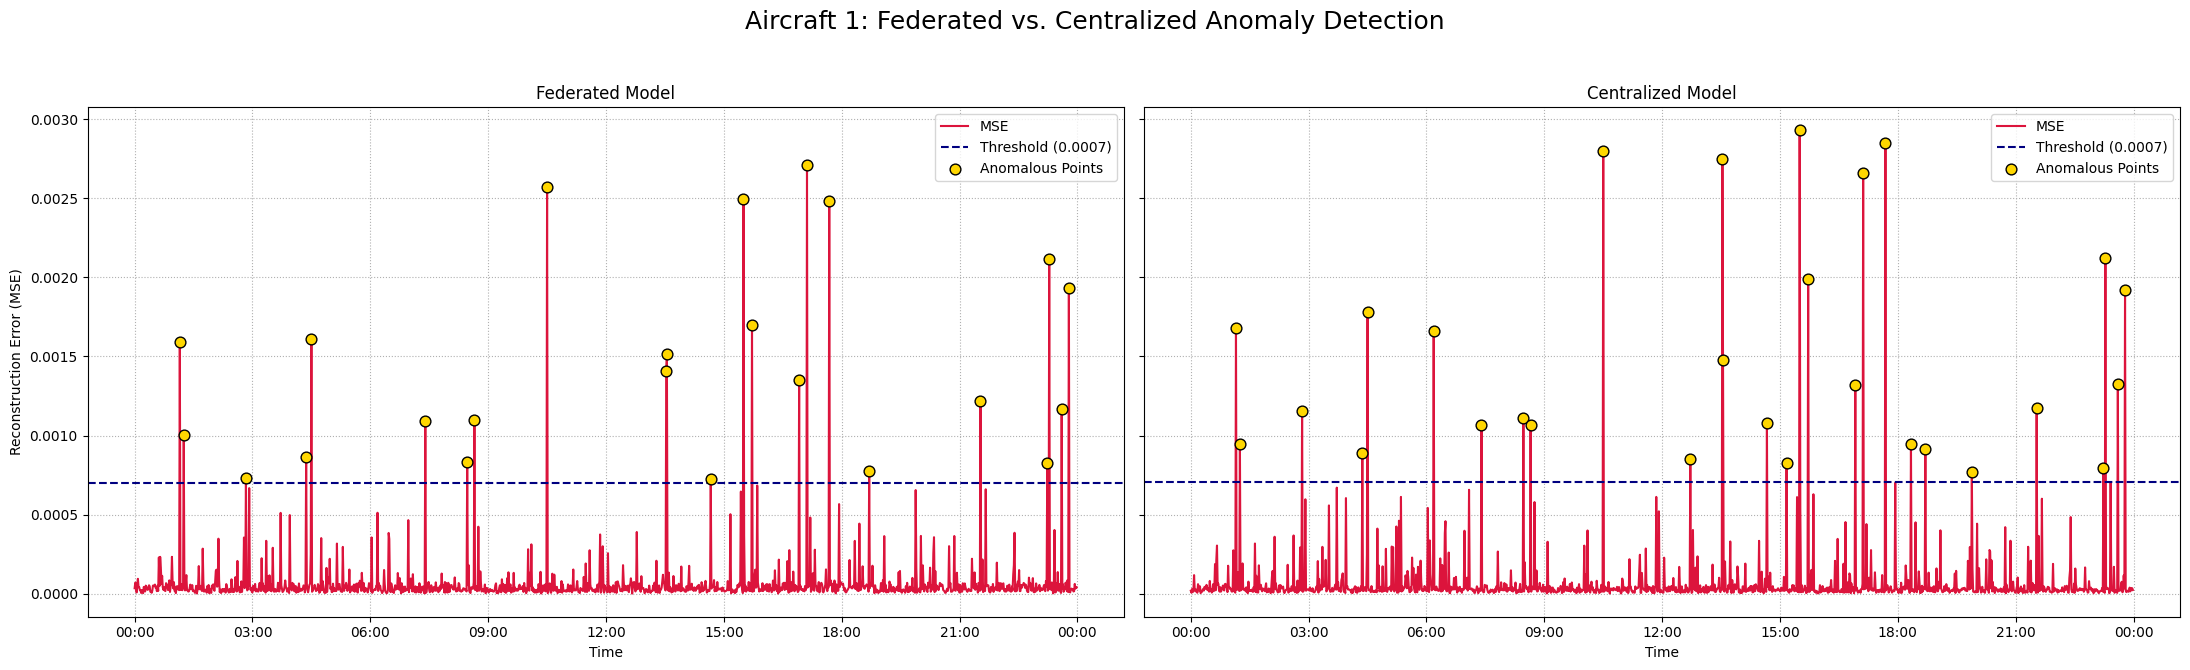

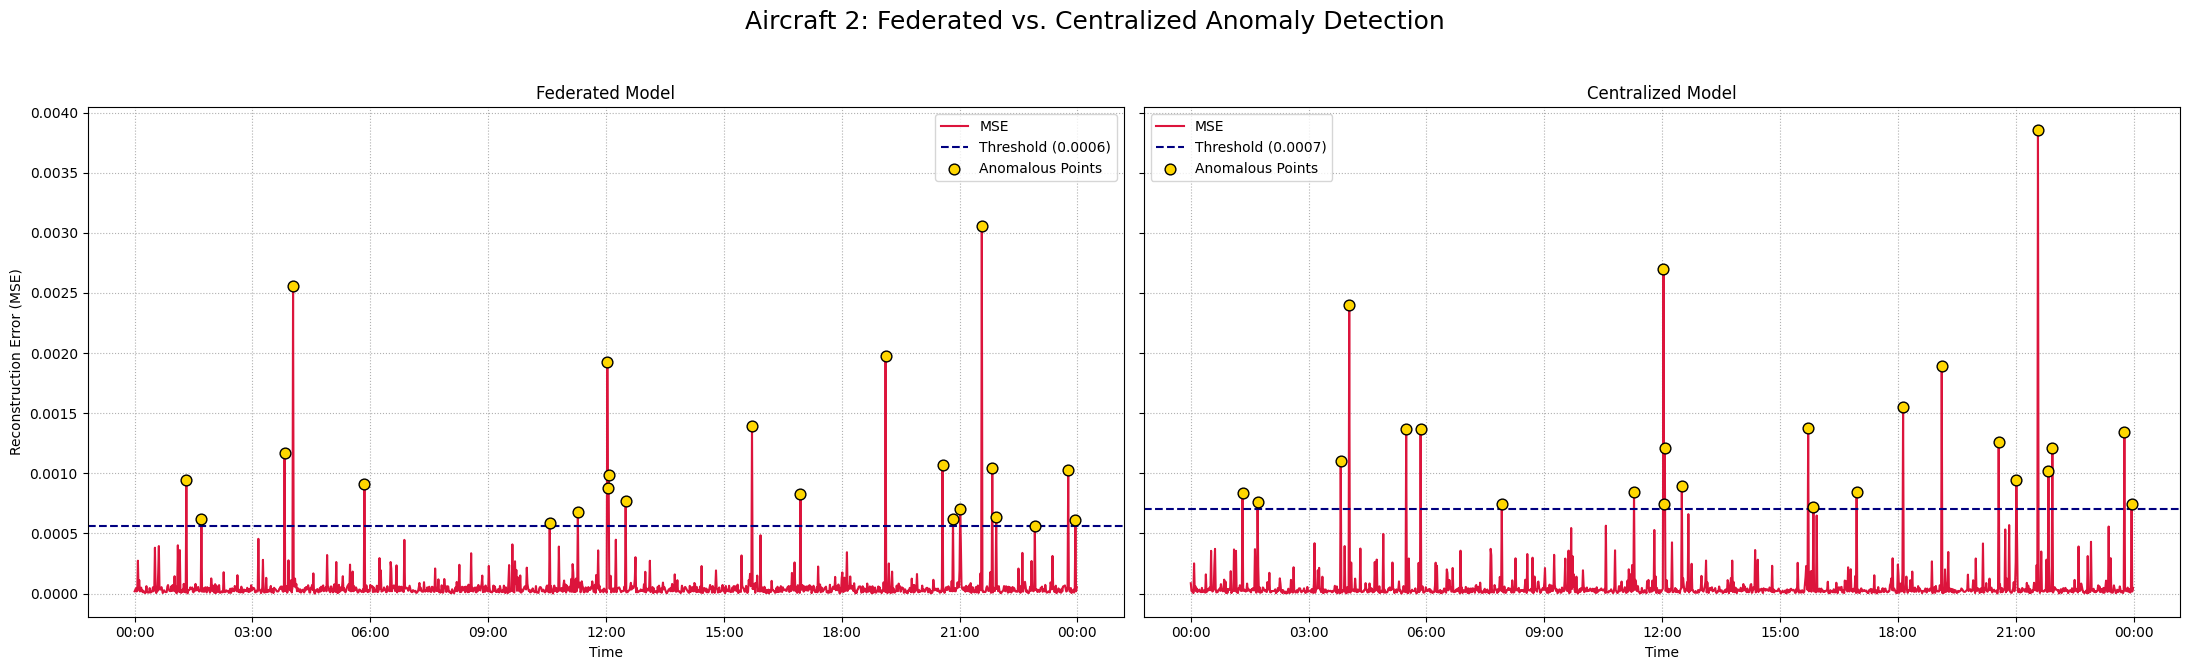

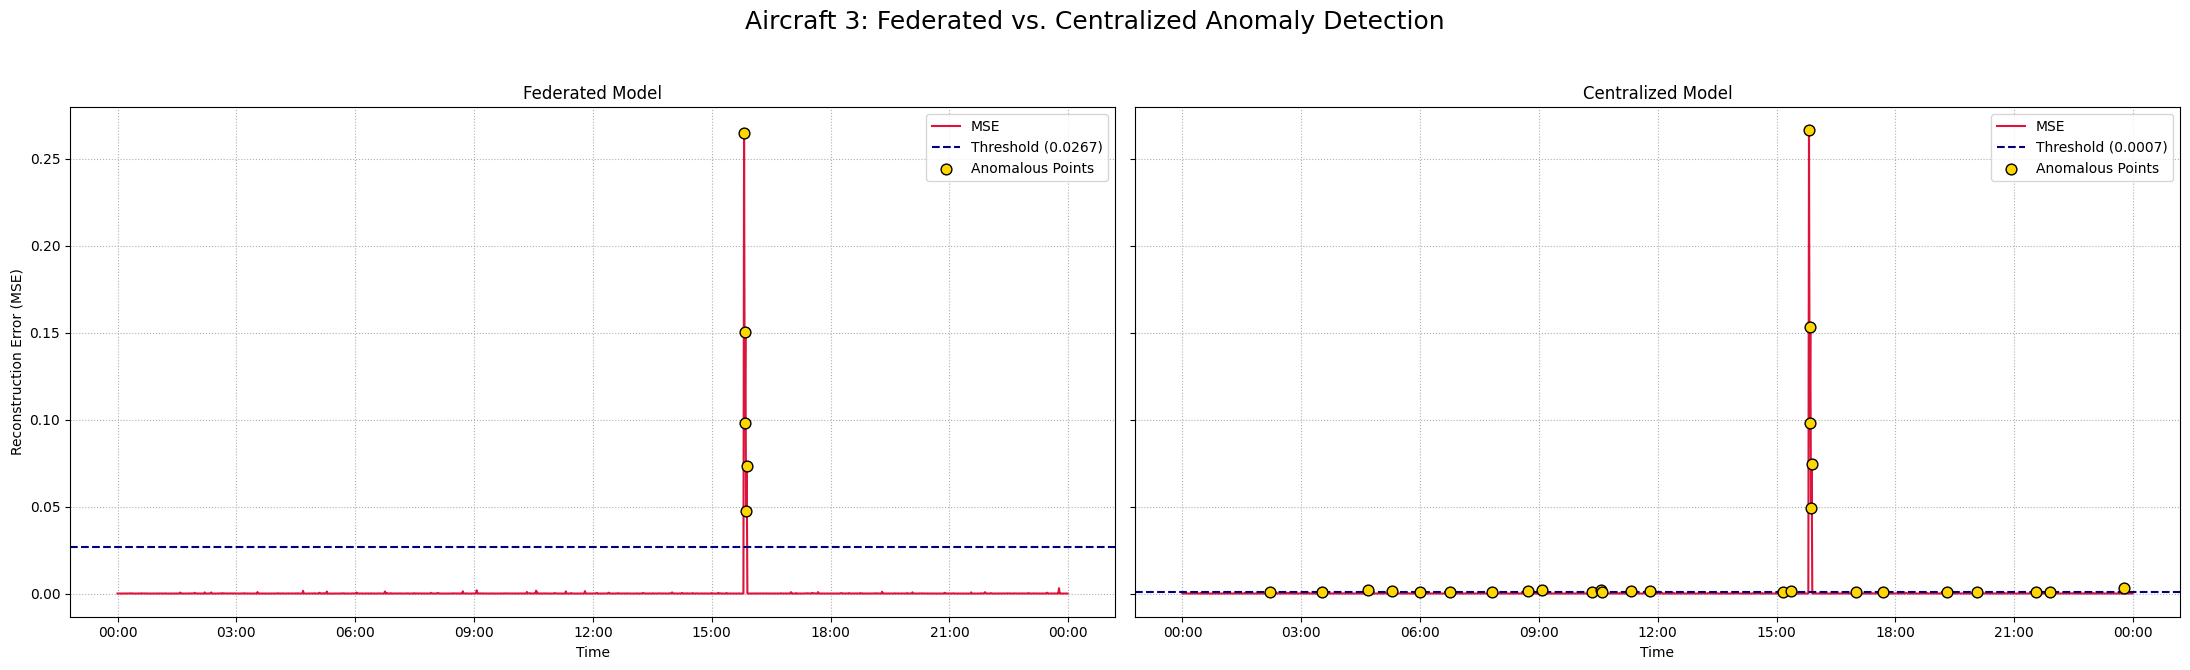

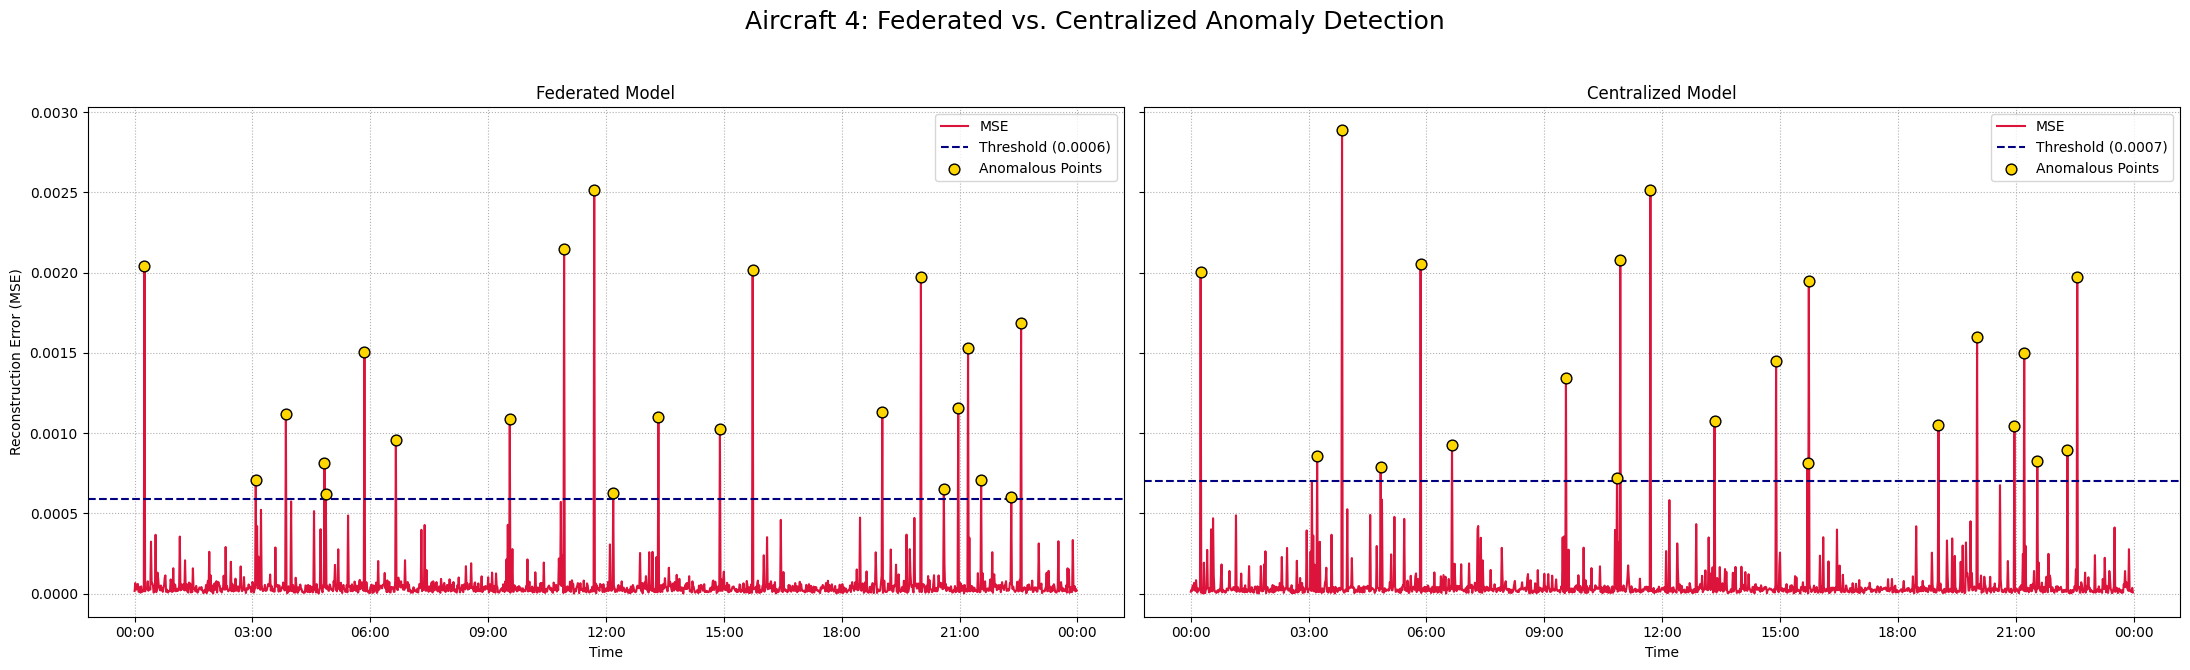

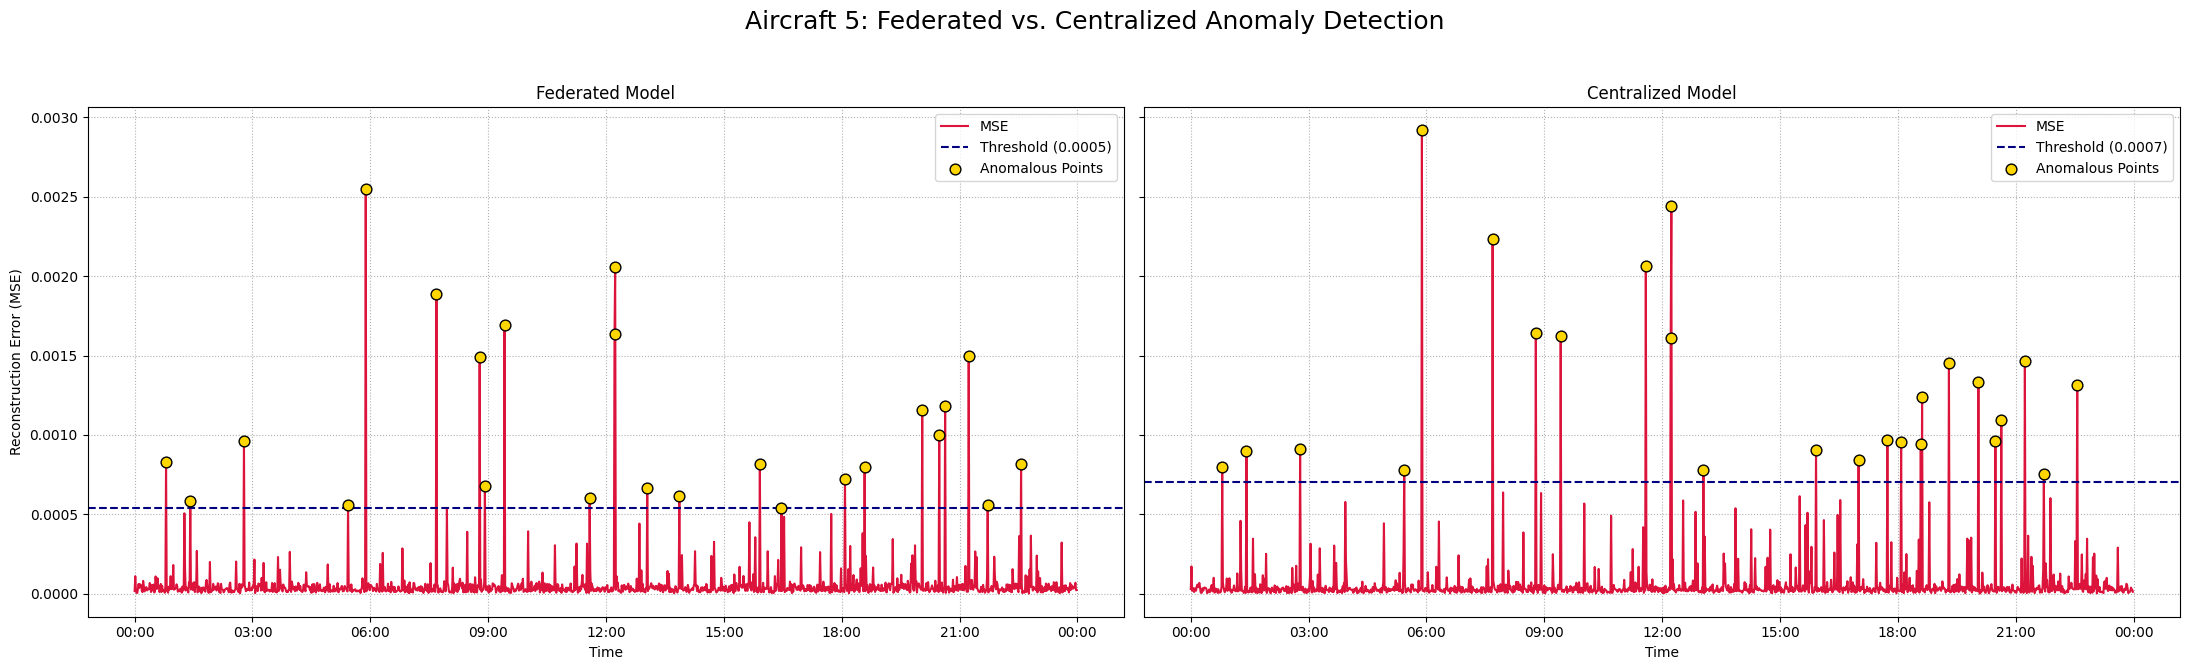

In [30]:
print("\n--- Generating Comparison Plots ---")

# Helper function to get reconstruction errors
def get_errors(model, data_tensor):
    with torch.no_grad():
        model.eval()
        reconstructed = model(data_tensor)
        return torch.mean((data_tensor - reconstructed)**2, dim=1).numpy()

# Generate a plot for each aircraft
for i, file_path in enumerate(file_paths):
    client_id = i + 1
    
    # Load the aircraft's full dataset
    client_df = pd.read_csv(file_path)
    timestamps = pd.to_datetime(client_df['timestamp'])
    
    # Scale data using the GLOBAL scaler
    client_tensor = torch.tensor(scaler.transform(client_df[DATA_CONFIG['sensor_names']]), dtype=torch.float32)

    # Get errors and threshold for Federated Model
    fed_errors = get_errors(federated_model, client_tensor)
    fed_threshold = np.mean(fed_errors) + 3 * np.std(fed_errors)
    fed_anomalies = fed_errors > fed_threshold

    # Get errors and threshold for Centralized Model
    cen_errors = get_errors(centralized_model, client_tensor)
    normal_data_errors = get_errors(centralized_model, train_tensor)
    cen_threshold = np.mean(normal_data_errors) + 3 * np.std(normal_data_errors)
    cen_anomalies = cen_errors > cen_threshold

    # Create the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
    fig.suptitle(f'Aircraft {client_id}: Federated vs. Centralized Anomaly Detection', fontsize=18)

    # Federated Plot
    ax1.plot(timestamps, fed_errors, label='MSE', color='crimson')
    ax1.axhline(fed_threshold, color='navy', linestyle='--', label=f'Threshold ({fed_threshold:.4f})')
    ax1.scatter(timestamps[fed_anomalies], fed_errors[fed_anomalies], s=60, color='gold', edgecolor='black', label='Anomalous Points', zorder=5)
    ax1.set_title('Federated Model')
    ax1.set_ylabel("Reconstruction Error (MSE)"); ax1.set_xlabel("Time")
    ax1.grid(True, which='both', linestyle=':'); ax1.legend()
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    # Centralized Plot
    ax2.plot(timestamps, cen_errors, label='MSE', color='crimson')
    ax2.axhline(cen_threshold, color='navy', linestyle='--', label=f'Threshold ({cen_threshold:.4f})')
    ax2.scatter(timestamps[cen_anomalies], cen_errors[cen_anomalies], s=60, color='gold', edgecolor='black', label='Anomalous Points', zorder=5)
    ax2.set_title('Centralized Model')
    ax2.set_xlabel("Time")
    ax2.grid(True, which='both', linestyle=':'); ax2.legend()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

In [31]:
print("\n--- Model Performance Statistics ---")

centralized_stats = []
federated_stats = []

# Ensure models are in evaluation mode
centralized_model.eval()
federated_model.eval()

# Use the same globally-fitted scaler for a fair comparison
# This 'scaler' object was fitted on the combined normal data during centralized training
global_scaler = scaler

with torch.no_grad():
    for i, file_path in enumerate(file_paths):
        client_id = i + 1
        df = pd.read_csv(file_path)
        sensor_data = df[DATA_CONFIG['sensor_names']]
        n_points = len(sensor_data)
        
        # Scale data using the single global scaler
        scaled_data = global_scaler.transform(sensor_data)
        data_tensor = torch.tensor(scaled_data, dtype=torch.float32)
        
        # --- Centralized Model Evaluation ---
        reconstructed_centralized = centralized_model(data_tensor)
        # Calculate per-point MSE loss
        mse_centralized = torch.mean((data_tensor - reconstructed_centralized)**2, dim=1)
        centralized_stats.append({
            'client_id': client_id,
            'status': 'Anomalous' if "anomalous" in file_path else 'Normal',
            'mean_mse': mse_centralized.mean().item(),
            'max_mse': mse_centralized.max().item(),
            'std_mse': mse_centralized.std().item(),
            'n_points': n_points
        })
        
        # --- Federated Model Evaluation ---
        reconstructed_federated = federated_model(data_tensor)
        # Calculate per-point MSE loss
        mse_federated = torch.mean((data_tensor - reconstructed_federated)**2, dim=1)
        federated_stats.append({
            'client_id': client_id,
            'status': 'Anomalous' if "anomalous" in file_path else 'Normal',
            'mean_mse': mse_federated.mean().item(),
            'max_mse': mse_federated.max().item(),
            'std_mse': mse_federated.std().item(),
            'n_points': n_points
        })

# Create DataFrames for a clean display
centralized_df = pd.DataFrame(centralized_stats).set_index('client_id')
federated_df = pd.DataFrame(federated_stats).set_index('client_id')

# Set pandas display options for better readability
pd.set_option('display.float_format', '{:.6f}'.format)

print("\n--- Centralized Model Performance ---")
display(centralized_df[['status', 'mean_mse', 'max_mse', 'std_mse', 'n_points']])

print("\n--- Federated Model Performance ---")
display(federated_df[['status', 'mean_mse', 'max_mse', 'std_mse', 'n_points']])


--- Model Performance Statistics ---

--- Centralized Model Performance ---


,status,mean_mse,max_mse,std_mse,n_points
client_id,,,,,
1,Normal,0.000079,0.002929,0.000243,1440
2,Normal,0.000068,0.003851,0.000203,1440
3,Anomalous,0.000509,0.266360,0.008805,1440
4,Normal,0.000066,0.002886,0.000198,1440
5,Normal,0.000066,0.002918,0.000198,1440



--- Federated Model Performance ---


,status,mean_mse,max_mse,std_mse,n_points
client_id,,,,,
1,Normal,0.000073,0.002713,0.000208,1440
2,Normal,0.000061,0.003059,0.000166,1440
3,Anomalous,0.000500,0.264673,0.008726,1440
4,Normal,0.000063,0.002518,0.000176,1440
5,Normal,0.000060,0.002552,0.000160,1440



--- Visualizing Performance Statistics ---


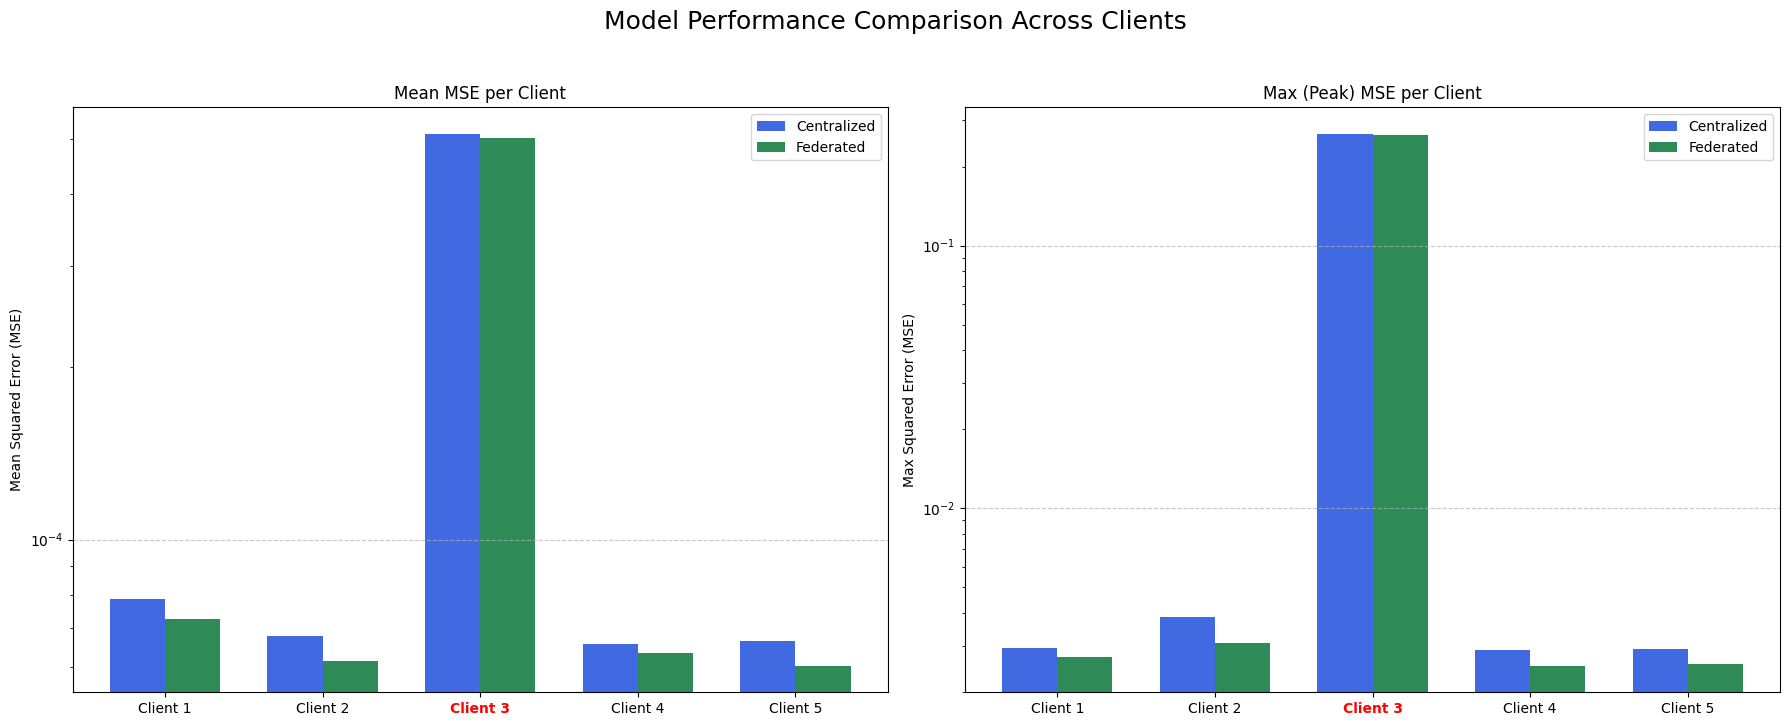

In [32]:
print("\n--- Visualizing Performance Statistics ---")

# Create a figure for the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Performance Comparison Across Clients', fontsize=18, y=1.03)

# --- Bar Chart for Mean MSE ---
bar_width = 0.35
client_ids = centralized_df.index
x = np.arange(len(client_ids))

rects1 = ax1.bar(x - bar_width/2, centralized_df['mean_mse'], bar_width, label='Centralized', color='royalblue')
rects2 = ax1.bar(x + bar_width/2, federated_df['mean_mse'], bar_width, label='Federated', color='seagreen')

ax1.set_ylabel('Mean Squared Error (MSE)')
ax1.set_title('Mean MSE per Client')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Client {id}' for id in client_ids])
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_yscale('log') # Use log scale for better visibility

# --- Bar Chart for Max MSE ---
rects3 = ax2.bar(x - bar_width/2, centralized_df['max_mse'], bar_width, label='Centralized', color='royalblue')
rects4 = ax2.bar(x + bar_width/2, federated_df['max_mse'], bar_width, label='Federated', color='seagreen')

ax2.set_ylabel('Max Squared Error (MSE)')
ax2.set_title('Max (Peak) MSE per Client')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Client {id}' for id in client_ids])
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_yscale('log') # Log scale is useful for comparing large spikes

# Add a visual indicator for the anomalous client
for ax in [ax1, ax2]:
    for i, client_id in enumerate(client_ids):
        # Find which client is anomalous from the dataframe status
        if centralized_df.loc[client_id, 'status'] == 'Anomalous':
            ax.get_xticklabels()[i].set_color('red')
            ax.get_xticklabels()[i].set_weight('bold')

fig.tight_layout()
plt.show()